In [1]:
# python
import sys
import importlib
# columnar analysis
from coffea import processor
# local
sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import sidm_processor, llpnanoaodschema, utilities
importlib.reload(sidm_processor)
importlib.reload(llpnanoaodschema)
importlib.reload(utilities)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()

In [2]:
samples = [
    '2Mu2E_500GeV_5p0GeV_8p0mm',
    'DoubleMuon_2018C',
]
fileset = utilities.make_fileset([samples[0]], "llpNanoAOD_v2", max_files=1, location_cfg="signal_2mu2e_v10.yaml")

runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    schema=llpnanoaodschema.LLPNanoAODSchema,
    maxchunks=1,
    skipbadfiles=True,
    chunksize=11_000,
)

channels = [
    "2mu2e",
]
p = sidm_processor.SidmProcessor(
    channels,
    ["base"],
    verbose=False,
)

output = runner.run(fileset, treename='Events', processor_instance=p)
out = output["out"]

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value 
encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

2Mu2E_500GeV_5p0GeV_8p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb


In [3]:
out[samples[0]]["cutflow"][channels[0]].print_table()

cut name                             raw N    weighted N    weighted %
---------------------------------  -------  ------------  ------------
None                                4364.0          59.8         100.0
pass triggers                       1502.0          20.6          34.4
PV filter                           1502.0          20.6          34.4
>=2 LJs                             1259.0          17.3          28.8
>=2 muons (pf or dsa) pT > 26 GeV   1029.0          14.1          23.6
2mu2e                               1023.0          14.0          23.4


[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f738a853980>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

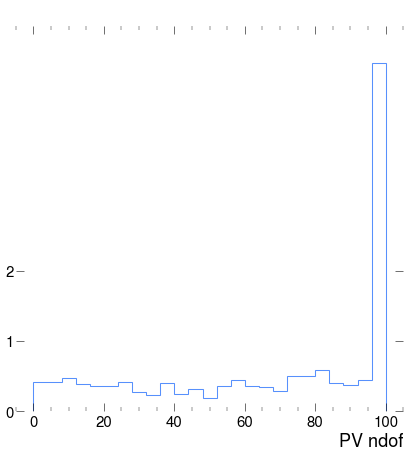

In [4]:
utilities.plot(out[samples[0]]["hists"]["pv_ndof"][channels[0], :])

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7f738923c0e0>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f738a4060c0>, text=[])

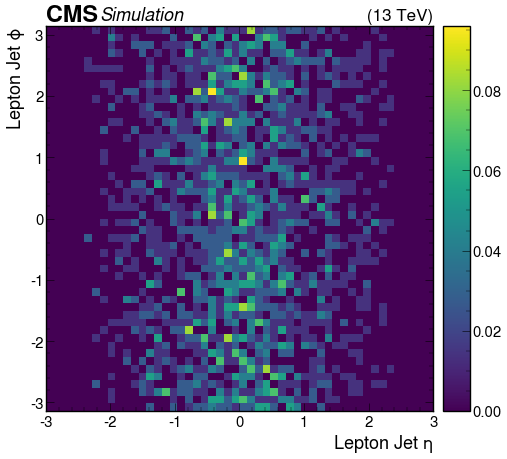

In [6]:
utilities.plot(out[samples[0]]["hists"]["lj_eta_phi"][channels[0], :, :])

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f7389f88ce0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

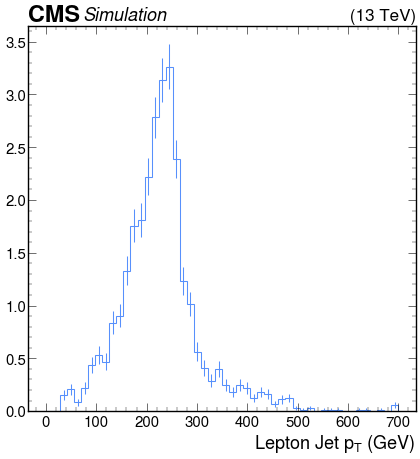

In [7]:
utilities.plot(out[samples[0]]["hists"]["lj_pt"][channels[0], ::2j])

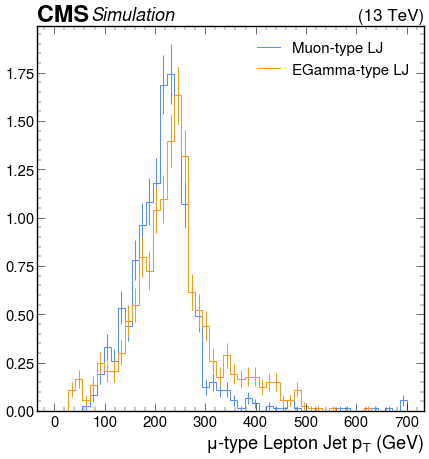

In [8]:
utilities.plot([
    out[samples[0]]["hists"]["mu_lj_pt"][channels[0], ::2j],
    out[samples[0]]["hists"]["egm_lj_pt"][channels[0], ::2j],
])
plt.legend(["Muon-type LJ", "EGamma-type LJ"])

/home/cms-jovyan/SIDM/sidm/tools/utilities.py:190: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/SIDM/sidm/tools/utilities.py:195: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/SIDM/sidm/tools/utilities.py:196: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()


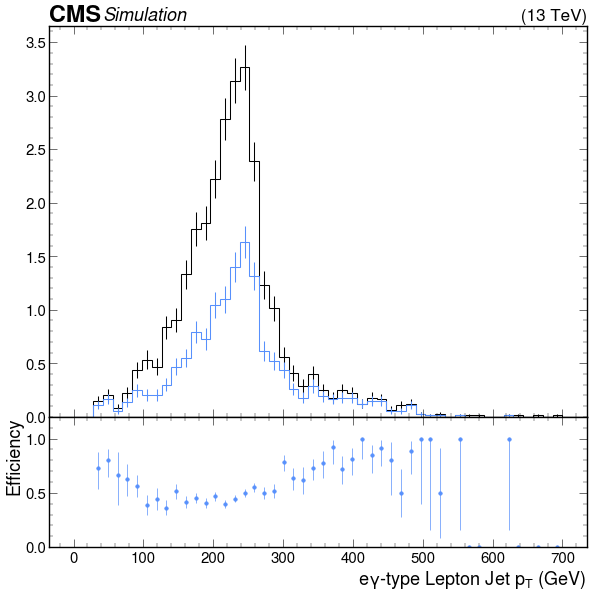

In [9]:
utilities.plot_ratio(
        out[samples[0]]["hists"]["egm_lj_pt"][channels[0], ::2j],
        out[samples[0]]["hists"]["lj_pt"][channels[0], ::2j],
)

In [10]:
# test processing of data. Note that we are only running over one file, so I am not worried about unblinding
fileset = utilities.make_fileset([samples[1]], "llpNanoAOD_v2", max_files=1, location_cfg="data.yaml")
output = runner.run(fileset, treename='Events', processor_instance=p)
out = output["out"]

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

Applying 2018 Golden JSON: 0 events removed

...

Warning: cannot fill counter Gen As to muons. Skipping.

Warning: cannot fill counter Gen As to electrons. Skipping.

Warning: cannot fill counter Matched gen As to muons. Skipping.

Warning: cannot fill counter Matched gen As to electrons. Skipping.

DoubleMuon_2018C is data. Not scaling histograms or cutflows.


In [11]:
out[samples[1]]["cutflow"][channels[0]].print_table()

cut name                             raw N    weighted N    weighted %
---------------------------------  -------  ------------  ------------
None                               10982.0       10982.0         100.0
pass triggers                       3078.0        3078.0          28.0
PV filter                           3076.0        3076.0          28.0
>=2 LJs                             1195.0        1195.0          10.9
>=2 muons (pf or dsa) pT > 26 GeV   1186.0        1186.0          10.8
2mu2e                                  2.0           2.0           0.0


[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f7363e6b7a0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

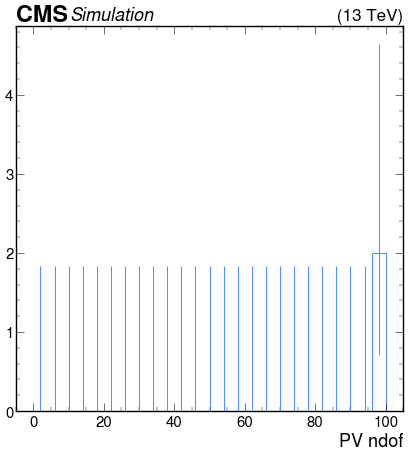

In [12]:
utilities.plot(out[samples[1]]["hists"]["pv_ndof"][channels[0], :])

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7f735a09eab0>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f73572f2de0>, text=[])

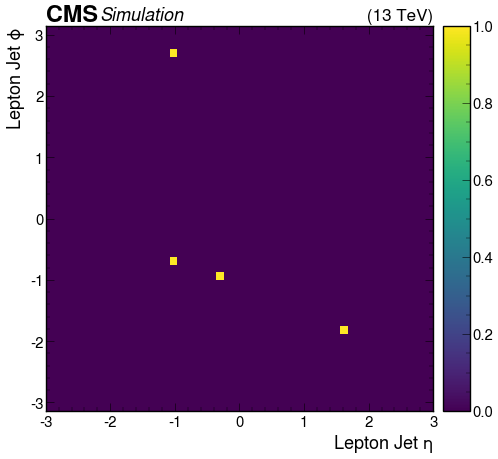

In [17]:
utilities.plot(out[samples[1]]["hists"]["lj_eta_phi"][channels[0], :, :])

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f735734ac00>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

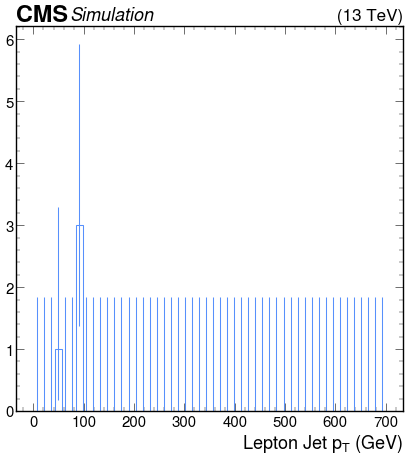

In [18]:
utilities.plot(out[samples[1]]["hists"]["lj_pt"][channels[0], ::2j])

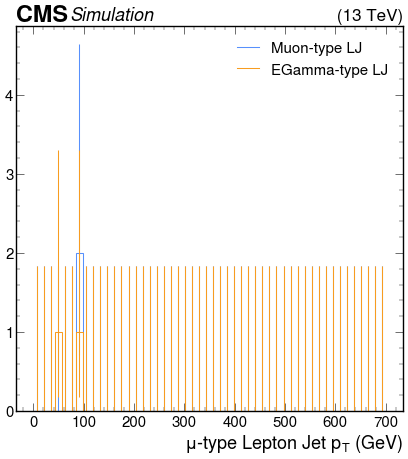

In [19]:
utilities.plot([
    out[samples[1]]["hists"]["mu_lj_pt"][channels[0], ::2j],
    out[samples[1]]["hists"]["egm_lj_pt"][channels[0], ::2j],
])
plt.legend(["Muon-type LJ", "EGamma-type LJ"])

/home/cms-jovyan/SIDM/sidm/tools/utilities.py:190: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/SIDM/sidm/tools/utilities.py:195: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/SIDM/sidm/tools/utilities.py:196: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()


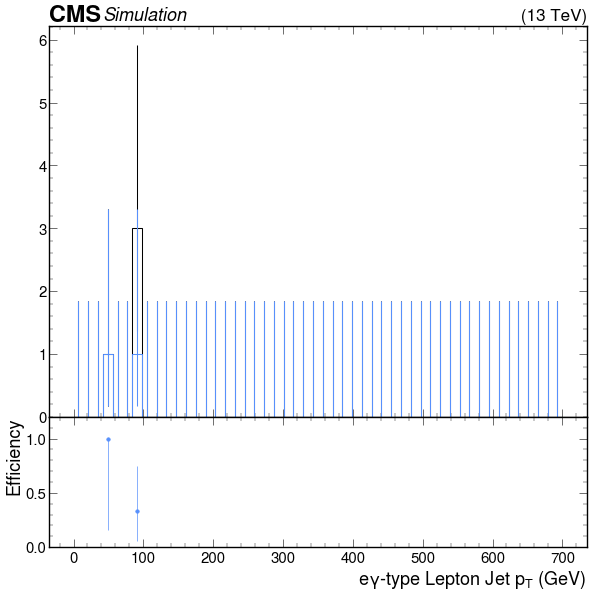

In [20]:
utilities.plot_ratio(
    out[samples[1]]["hists"]["egm_lj_pt"][channels[0], ::2j],
    out[samples[1]]["hists"]["lj_pt"][channels[0], ::2j],
)